<a href="https://colab.research.google.com/github/AichaELMouta/GiveMeSomeCreditClassification/blob/main/CreditClassificationML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
creditdata = pd.read_csv('cs-training.csv')

In [3]:
creditdata.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45.0,2.0,0.802982,9120.0,13.0,0.0,6.0,0.0,2.0
1,2,0,0.957151,40.0,0.0,0.121876,2600.0,4.0,0.0,0.0,0.0,1.0
2,3,0,0.658180,38.0,1.0,0.085113,3042.0,2.0,1.0,0.0,0.0,0.0
3,4,0,0.233810,30.0,0.0,0.036050,3300.0,5.0,0.0,0.0,0.0,0.0
4,5,0,0.907239,49.0,1.0,0.024926,63588.0,7.0,0.0,1.0,0.0,0.0


In [4]:
creditdata.columns


Index(['Unnamed: 0', 'SeriousDlqin2yrs',
       'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

Understanding Columns:
1.  SeriousDlqin2yrs
2.  RevolvingUtilizationOfUnsecuredLines
1.  age
2.  NumberOfTime30-59DaysPastDueNotWorse
1.  DebtRatio
2.  MonthlyIncome
1.  NumberOfOpenCreditLinesAndLoans
2.  NumberOfTimes90DaysLate
1.  NumberRealEstateLoansOrLines
2.  NumberOfTime60-89DaysPastDueNotWorse
1.  NumberOfDependents


















In [5]:
creditdata.shape

(83832, 12)

In [6]:
creditdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83832 entries, 0 to 83831
Data columns (total 12 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Unnamed: 0                            83832 non-null  int64  
 1   SeriousDlqin2yrs                      83832 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  83831 non-null  float64
 3   age                                   83831 non-null  float64
 4   NumberOfTime30-59DaysPastDueNotWorse  83831 non-null  float64
 5   DebtRatio                             83831 non-null  float64
 6   MonthlyIncome                         67212 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       83831 non-null  float64
 8   NumberOfTimes90DaysLate               83831 non-null  float64
 9   NumberRealEstateLoansOrLines          83831 non-null  float64
 10  NumberOfTime60-89DaysPastDueNotWorse  83831 non-null  float64
 11  NumberOfDepende

In [7]:
creditdata[creditdata.duplicated(keep=False)]

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents


In [8]:
creditdata.isnull().sum()

,0
Unnamed: 0,0
SeriousDlqin2yrs,0
RevolvingUtilizationOfUnsecuredLines,1
age,1
NumberOfTime30-59DaysPastDueNotWorse,1
DebtRatio,1
MonthlyIncome,16620
NumberOfOpenCreditLinesAndLoans,1
NumberOfTimes90DaysLate,1
NumberRealEstateLoansOrLines,1


In [9]:
null_rows = creditdata[creditdata['MonthlyIncome'].isna()]
null_rows

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
6,7,0,0.305682,57.0,0.0,5710.0,NaN,8.0,0.0,3.0,0.0,0.0
8,9,0,0.116951,27.0,0.0,46.0,NaN,2.0,0.0,0.0,0.0,NaN
16,17,0,0.061086,78.0,0.0,2058.0,NaN,10.0,0.0,2.0,0.0,0.0
32,33,0,0.083418,62.0,0.0,977.0,NaN,6.0,0.0,1.0,0.0,0.0
41,42,0,0.072898,81.0,0.0,75.0,NaN,7.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
83824,83825,0,0.006040,52.0,0.0,1048.0,NaN,4.0,0.0,0.0,0.0,0.0
83825,83826,0,0.027383,72.0,0.0,1881.0,NaN,11.0,0.0,2.0,0.0,0.0
83827,83828,0,0.029585,61.0,0.0,2528.0,NaN,11.0,0.0,1.0,0.0,0.0
83830,83831,0,0.022041,64.0,0.0,2400.0,NaN,5.0,0.0,2.0,0.0,2.0


In [10]:
null_rows_dependent = creditdata[creditdata['NumberOfDependents'].isna()]
null_rows_dependent

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
8,9,0,0.116951,27.0,0.0,46.0,NaN,2.0,0.0,0.0,0.0,NaN
96,97,0,0.542243,48.0,2.0,10.0,NaN,2.0,0.0,0.0,0.0,NaN
109,110,0,0.041258,61.0,0.0,4739.0,NaN,11.0,0.0,4.0,0.0,NaN
159,160,0,0.000000,63.0,0.0,2.0,NaN,4.0,0.0,0.0,0.0,NaN
238,239,0,1.000000,28.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
83727,83728,0,1.000000,41.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,NaN
83756,83757,0,0.066048,62.0,0.0,2025.0,NaN,7.0,0.0,1.0,0.0,NaN
83774,83775,0,0.000000,61.0,0.0,14.0,NaN,3.0,0.0,0.0,0.0,NaN
83785,83786,0,0.018380,77.0,0.0,11.0,NaN,6.0,0.0,0.0,0.0,NaN


In [11]:
creditdata.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,83832.00000,83832.000000,83831.000000,83831.000000,83831.000000,83831.000000,6.721200e+04,83831.000000,83831.000000,83831.000000,83831.000000,81625.000000
mean,41916.50000,0.066311,5.536967,52.229939,0.425499,360.593331,6.636381e+03,8.436521,0.271880,1.019003,0.245279,0.757648
std,24200.35822,0.248827,215.233975,14.767151,4.255681,2264.596318,1.428700e+04,5.145682,4.231905,1.131963,4.219076,1.115345
min,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20958.75000,0.000000,0.029797,41.000000,0.000000,0.174760,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,41916.50000,0.000000,0.155422,52.000000,0.000000,0.366579,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,62874.25000,0.000000,0.562133,63.000000,0.000000,0.867746,8.250000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,83832.00000,1.000000,29110.000000,107.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [12]:
creditdata['MonthlyIncome_missing'] = creditdata['MonthlyIncome'].isnull().astype(int)

In [13]:
creditdata['MonthlyIncome_missing'].head()

,MonthlyIncome_missing
0,0
1,0
2,0
3,0
4,0


In [14]:
creditdata[creditdata['NumberOfDependents'].isna()]


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_missing
8,9,0,0.116951,27.0,0.0,46.0,NaN,2.0,0.0,0.0,0.0,NaN,1
96,97,0,0.542243,48.0,2.0,10.0,NaN,2.0,0.0,0.0,0.0,NaN,1
109,110,0,0.041258,61.0,0.0,4739.0,NaN,11.0,0.0,4.0,0.0,NaN,1
159,160,0,0.000000,63.0,0.0,2.0,NaN,4.0,0.0,0.0,0.0,NaN,1
238,239,0,1.000000,28.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
83727,83728,0,1.000000,41.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,NaN,1
83756,83757,0,0.066048,62.0,0.0,2025.0,NaN,7.0,0.0,1.0,0.0,NaN,1
83774,83775,0,0.000000,61.0,0.0,14.0,NaN,3.0,0.0,0.0,0.0,NaN,1
83785,83786,0,0.018380,77.0,0.0,11.0,NaN,6.0,0.0,0.0,0.0,NaN,1


In [15]:
creditdata.groupby('MonthlyIncome_missing')['SeriousDlqin2yrs'].mean()

,SeriousDlqin2yrs
MonthlyIncome_missing,
0,0.068648
1,0.056859


<Axes: xlabel='MonthlyIncome_missing', ylabel='DebtRatio'>

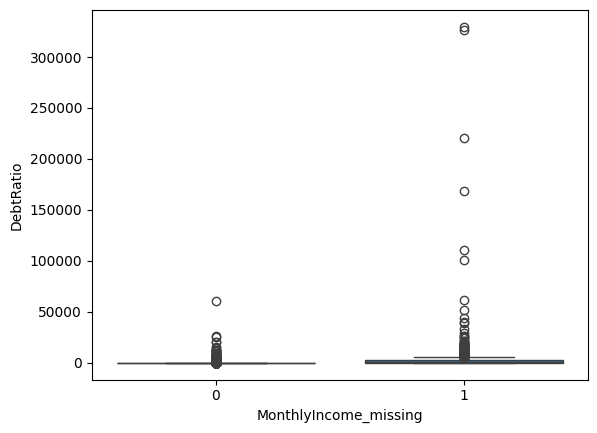

In [16]:
import seaborn as sns
sns.boxplot(x='MonthlyIncome_missing', y='DebtRatio', data=creditdata)

In [17]:
from scipy.stats import chi2_contingency
contingency_table = pd.crosstab(creditdata['MonthlyIncome_missing'], creditdata['SeriousDlqin2yrs'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-squared statistic: {chi2}")
print(f"P-value: {p}")

Chi-squared statistic: 29.722296411243114
P-value: 4.98580625273476e-08


p_value << 0.05 that means there is statistically significant relationship between missing income and default risk.

In [18]:
creditdata['NumberOfDependents'].value_counts()

,count
NumberOfDependents,
0.0,48489
1.0,14855
2.0,10812
3.0,5279
4.0,1630
5.0,434
6.0,84
7.0,25
8.0,10


In [19]:
creditdata['NumberOfDependents_missing'] = creditdata['NumberOfDependents'].isnull().astype(int)

In [20]:
creditdata.groupby('NumberOfDependents_missing')['SeriousDlqin2yrs'].mean()

,SeriousDlqin2yrs
NumberOfDependents_missing,
0,0.066965
1,0.042139


In [22]:
contingency_table = pd.crosstab(creditdata['NumberOfDependents_missing'], creditdata['SeriousDlqin2yrs'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-squared statistic: {chi2}")
print(f"P-value: {p}")

Chi-squared statistic: 20.99257146060981
P-value: 4.610676265671336e-06


The chi-square test shows a statistically significant association between missing values in NumberOfDependents and SeriousDlqin2yrs (p < 0.05). Applicants with missing dependents have a lower observed default rate, suggesting that missingness carries predictive information.

In [24]:
print('Skewness coeficient',creditdata['age'].skew())

Skewness coeficient 0.1833442942753604


In [28]:
if "Unnamed: 0" in creditdata.columns:
    creditdata = creditdata.drop(columns=["Unnamed: 0"])

In [29]:
creditdata.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_missing,NumberOfDependents_missing
0,1,0.766127,45.0,2.0,0.802982,9120.0,13.0,0.0,6.0,0.0,2.0,0,0
1,0,0.957151,40.0,0.0,0.121876,2600.0,4.0,0.0,0.0,0.0,1.0,0,0
2,0,0.658180,38.0,1.0,0.085113,3042.0,2.0,1.0,0.0,0.0,0.0,0,0
3,0,0.233810,30.0,0.0,0.036050,3300.0,5.0,0.0,0.0,0.0,0.0,0,0
4,0,0.907239,49.0,1.0,0.024926,63588.0,7.0,0.0,1.0,0.0,0.0,0,0


EDA

In [31]:
creditdata.columns

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents', 'MonthlyIncome_missing',
       'NumberOfDependents_missing'],
      dtype='object')

In [32]:
import plotly.express as px
px.histogram(creditdata , x = 'age' ,  text_auto = '.1f' , title = 'age Range')

In [33]:
px.histogram(creditdata , x = 'RevolvingUtilizationOfUnsecuredLines' ,  text_auto = '.1f' , title = 'age Range')